### **FASE 10: CLUSTERING + PCA**

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Montar Drive
drive.mount('/content/drive', force_remount=False)

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("FASE 10: CLUSTERING + PCA - ENDES ANEMIA 2024")

Mounted at /content/drive
FASE 10: CLUSTERING + PCA - ENDES ANEMIA 2024


In [3]:
print("\n[1/8] Cargando datos escalados...")

df = pd.read_csv('/content/drive/MyDrive/endes-anemia2024-data/processed/05_data_scaled.csv')

print(f"✓ Datos escalados cargados: {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"✓ Columnas: {list(df.columns)}")


[1/8] Cargando datos escalados...
✓ Datos escalados cargados: 17,418 registros × 15 variables
✓ Columnas: ['HHID', 'num_nino', 'edad_nino', 'sexo_nino_code', 'anemia_nivel', 'HC60', 'cluster', 'estrato', 'ponderador_raw', 'quintil_raw', 'indice_riqueza', 'sexo_madre_code', 'edad_madre', 'edu_madre', 'edu_madre_det']


In [4]:
print("\n[2/8] Preparando datos para clustering...")

# Excluir identificadores
cols_exclude = ['HHID', 'num_nino'] if 'HHID' in df.columns else []
X = df.drop(cols_exclude, axis=1, errors='ignore')

print(f"✓ Variables para clustering: {X.shape[1]}")
print(f"✓ Observaciones: {X.shape[0]:,}")
print(f"✓ Datos ya escalados (Z-score)")


[2/8] Preparando datos para clustering...
✓ Variables para clustering: 13
✓ Observaciones: 17,418
✓ Datos ya escalados (Z-score)


In [5]:
print("\n[3/8] PCA: Reducción de Dimensionalidad...")

# PCA completo para varianza explicada
pca_full = PCA()
pca_full.fit(X)

# Varianza acumulada
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

print(f"\nVarianza explicada acumulada:")
print(f"  1 componente:  {cumvar[0]:>7.2%}")
print(f"  2 componentes: {cumvar[1]:>7.2%}")
print(f"  3 componentes: {cumvar[2]:>7.2%}")
print(f"  4 componentes: {cumvar[3]:>7.2%}")
print(f"  5 componentes: {cumvar[4]:>7.2%}")

# PCA con 2 componentes para visualización
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)

print(f"\n✓ PCA 2D: {pca2.explained_variance_ratio_[0]:.1%} + {pca2.explained_variance_ratio_[1]:.1%} = {sum(pca2.explained_variance_ratio_):.1%} varianza")



[3/8] PCA: Reducción de Dimensionalidad...

Varianza explicada acumulada:
  1 componente:  100.00%
  2 componentes: 100.00%
  3 componentes: 100.00%
  4 componentes: 100.00%
  5 componentes: 100.00%

✓ PCA 2D: 100.0% + 0.0% = 100.0% varianza



[4/8] Generando GRÁFICO 1: Scree Plot...


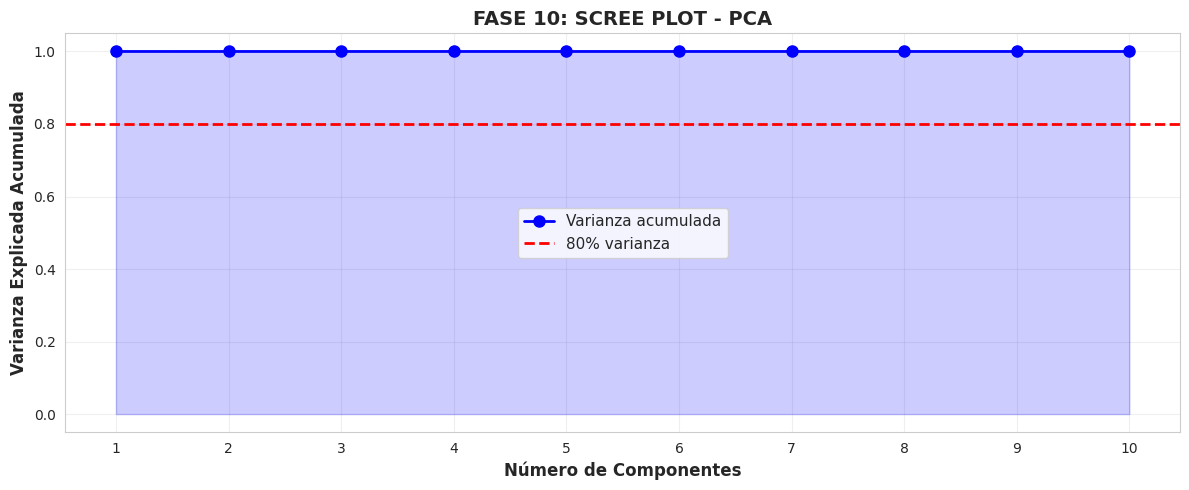

✓ Gráfico 1 completado


In [6]:
print("\n[4/8] Generando GRÁFICO 1: Scree Plot...")

fig, ax = plt.subplots(figsize=(12, 5))

# Varianza acumulada
ax.plot(range(1, 11), cumvar[:10], 'bo-', linewidth=2, markersize=8, label='Varianza acumulada')
ax.fill_between(range(1, 11), cumvar[:10], alpha=0.2, color='blue')

# Línea de referencia 80%
ax.axhline(y=0.80, color='red', linestyle='--', linewidth=2, label='80% varianza')

ax.set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
ax.set_ylabel('Varianza Explicada Acumulada', fontsize=12, fontweight='bold')
ax.set_title('FASE 10: SCREE PLOT - PCA', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Gráfico 1 completado")

MÉTODO DEL CODO: DETERMINAR K ÓPTIMO

In [7]:
print("\n[5/8] Método del Codo: Determinando k óptimo...")

inertias = []
silhouettes = []
ks = range(2, 11)

print(f"\nCalculando K-means para k = 2 a 10...")

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, verbose=0)
    km.fit(X_pca2)
    inertias.append(km.inertia_)

    # Silhouette
    sil_score = silhouette_score(X_pca2, km.labels_)
    silhouettes.append(sil_score)

    print(f"  k={k}: Inercia={km.inertia_:>10.2f}, Silhouette={sil_score:>7.4f}")


[5/8] Método del Codo: Determinando k óptimo...

Calculando K-means para k = 2 a 10...
  k=2: Inercia=308386160141580.31, Silhouette= 0.6293
  k=3: Inercia=162624740860382.66, Silhouette= 0.5530
  k=4: Inercia=81049835865827.27, Silhouette= 0.5860
  k=5: Inercia=56036119866771.43, Silhouette= 0.5639
  k=6: Inercia=40342870031247.37, Silhouette= 0.5688
  k=7: Inercia=28348465033655.10, Silhouette= 0.5762
  k=8: Inercia=22492617481714.79, Silhouette= 0.5651
  k=9: Inercia=17418087178164.16, Silhouette= 0.5694
  k=10: Inercia=14262604863343.84, Silhouette= 0.5584



[6/8] Generando GRÁFICO 2: Método del Codo...


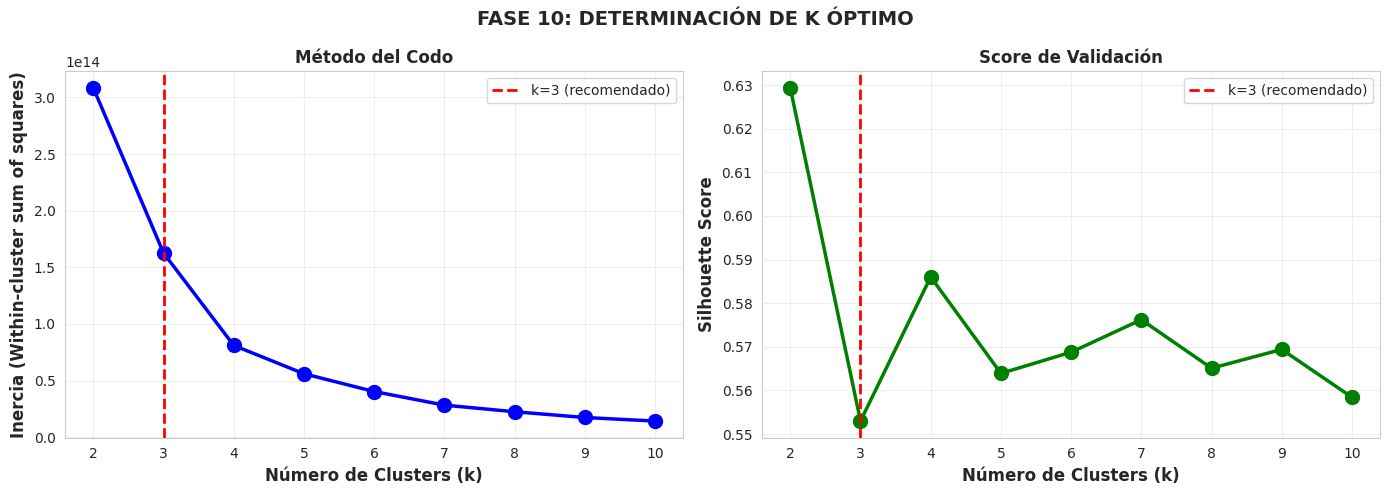

✓ Gráfico 2 completado


In [8]:
print("\n[6/8] Generando GRÁFICO 2: Método del Codo...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('FASE 10: DETERMINACIÓN DE K ÓPTIMO', fontsize=14, fontweight='bold')

# Inercia
ax1.plot(ks, inertias, 'bo-', linewidth=2.5, markersize=10)
ax1.axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (recomendado)')
ax1.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Inercia (Within-cluster sum of squares)', fontsize=12, fontweight='bold')
ax1.set_title('Método del Codo', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)

# Silhouette Score
ax2.plot(ks, silhouettes, 'go-', linewidth=2.5, markersize=10)
ax2.axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (recomendado)')
ax2.set_xlabel('Número de Clusters (k)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax2.set_title('Score de Validación', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Gráfico 2 completado")

K-MEANS CON K ÓPTIMO

In [9]:
print("\n[7/8] K-means Clustering (k=3)...")

k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca2)

print(f"\n✓ K-MEANS AJUSTADO (k={k_optimal})")
print(f"\nDistribución de clusters:")

unique, counts = np.unique(clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    percentage = count / len(clusters) * 100
    print(f"  Cluster {cluster}: {count:>6,} observaciones ({percentage:>5.1f}%)")

# Silhouette Score final
sil_final = silhouette_score(X_pca2, clusters)
print(f"\nSilhouette Score: {sil_final:.4f}")
print(f"Interpretación: ", end="")
if sil_final > 0.5:
    print("✓ BUENA cohesión de clusters")
elif sil_final > 0.3:
    print("⊙ MODERADA cohesión de clusters")
else:
    print("⚠ DÉBIL cohesión de clusters")


[7/8] K-means Clustering (k=3)...

✓ K-MEANS AJUSTADO (k=3)

Distribución de clusters:
  Cluster 0:  6,735 observaciones ( 38.7%)
  Cluster 1:  8,208 observaciones ( 47.1%)
  Cluster 2:  2,475 observaciones ( 14.2%)

Silhouette Score: 0.5530
Interpretación: ✓ BUENA cohesión de clusters



[8/8] Generando GRÁFICO 3: Visualización de Clusters...


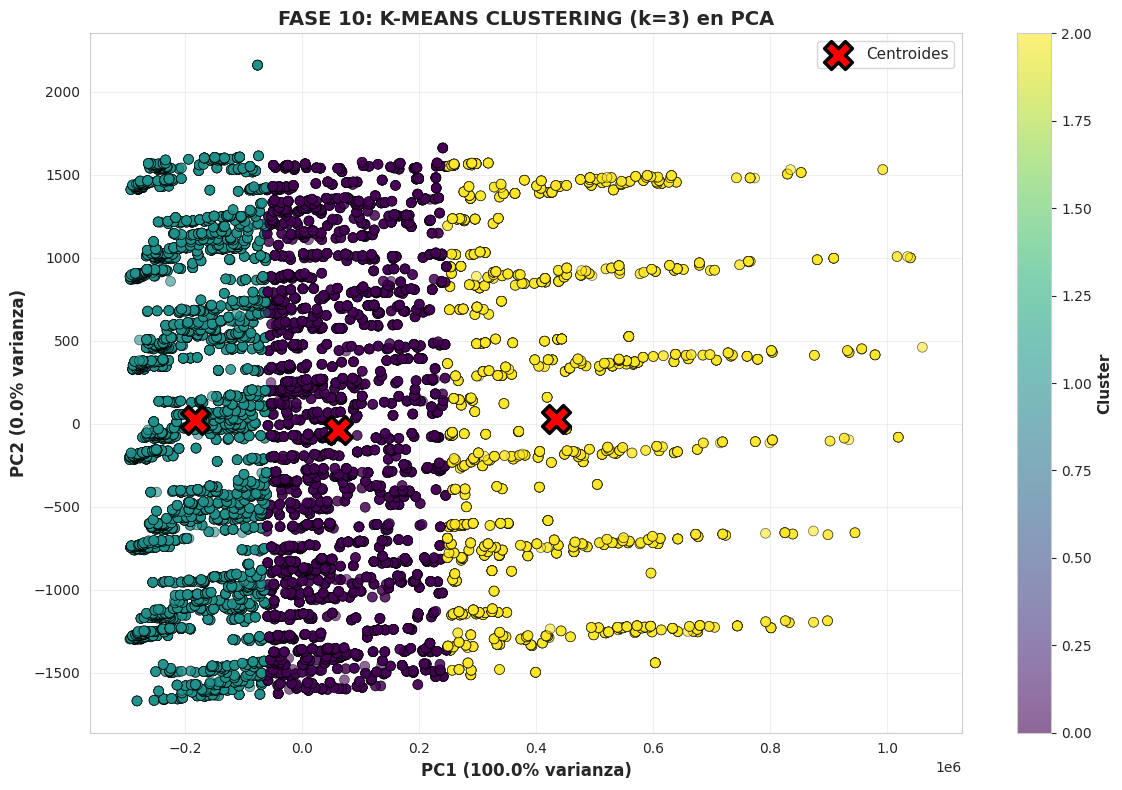

✓ Gráfico 3 completado


In [11]:
print("\n[8/8] Generando GRÁFICO 3: Visualización de Clusters...")

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot con clusters
scatter = ax.scatter(X_pca2[:, 0], X_pca2[:, 1],
                     c=clusters, cmap='viridis',
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Centros de clusters
centers_pca = kmeans.cluster_centers_
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
          c='red', marker='X', s=400, edgecolors='black', linewidth=2.5,
          label='Centroides', zorder=5)

# Etiquetas para centroides
for i, center in enumerate(centers_pca):
    ax.text(center[0], center[1], f'C{i}', fontsize=12, fontweight='bold',
            ha='center', va='center', color='white')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12, fontweight='bold')
ax.set_title(f'FASE 10: K-MEANS CLUSTERING (k={k_optimal}) en PCA', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax, label='Cluster')
cbar.set_label('Cluster', fontweight='bold', fontsize=11)

ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráfico 3 completado")